In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [68]:
df = pd.read_csv("/content/pyramids.csv")
df.head()

,Pharaoh,Ancient name,Modern name,Dynasty,Site,Base1 (m),Base2 (m),Height (m),Slope (dec degr),Volume (cu.m),Latitude,Longitude,Type,Lepsius,Material,Comment
0,Djoser,Hiemlender,Step Pyramid of Djoser,3,Saqqara,121.0,109.0,60.0,NaN,330.4,29.871215,31.216644,Step,XXXII,Mudbrick,NaN
1,Sekhemkhet,-,Buried Pyramid,3,Saqqara,120.0,120.0,70.0,NaN,33.6,29.866000,31.213000,Step,NaN,Mudbrick,(unfinished)
2,Khaba (?),-,Layer Pyramid,3,Zawyet el'Aryan,84.0,84.0,40.0,NaN,47.04,29.932820,31.161262,Step,XIV,Mudbrick,(unfinished)
3,Huni,-,Pyramid Lepsius I,3,Abu Rawash,215.0,215.0,145.0,NaN,NaN,30.040833,31.094444,Step,I,Mudbrick,totally ruined
4,Huni (?),-,Pyramid of Athribis,3,Athribis,20.0,20.0,16.0,50.0,NaN,30.470556,31.188056,Step,NaN,Mudbrick,NaN


#Dataset Definition: Ancient Pyramid Structural Dataset

##Overview

This dataset contains structured archaeological and geometric information about ancient Egyptian pyramids, focusing on their physical dimensions, geographic locations, construction attributes, and historical classification.

It is designed to support computational analysis of architectural patterns, enabling statistical and machine learning-based exploration of structural variation across early dynastic pyramid construction.

#What the dataset represents

Each row corresponds to a single pyramid structure and captures:

its historical identity (pharaoh + name)
its physical geometry (base, height, volume)
its geographical location (latitude, longitude, site)
its architectural classification (type, material, structure form)


#Feature Categories

Historical Attributes  

Pharaoh: Ruler associated with the pyramid construction
Ancient name: Original or historical designation
Modern name: Contemporary archaeological label
Dynasty: Egyptian dynastic period identifier

Purpose:
Helps link structural patterns to historical eras and ruling period

#Geographic Attributes

Site: Archaeological location (e.g., Saqqara, Giza region extensions)
Latitude / Longitude: Spatial coordinates of pyramid placement

Purpose:
Enables spatial analysis such as clustering, regional comparison, and geographic pattern detection.



#Structural Geometry
Base1 (m): Primary base length of pyramid footprint
Base2 (m): Secondary base width (for non-square bases or irregular structures)
Height (m): Vertical height of structure
Slope (dec degr): Construction angle in degrees (partially missing in dataset)
Volume (cu.m): Estimated structural volume

Purpose:
Forms the core feature set for geometric similarity analysis, clustering, and anomaly detection.

# Architectural Classification
Type: Structural category (e.g., Step Pyramid)
Lepsius: Historical catalog reference number
Material: Primary construction material (e.g., Mudbrick)

Purpose:
Allows grouping by construction style and material engineering techniques.

#Contextual Notes
Comment: Additional archaeological remarks (e.g., “unfinished”, “ruined”)

Purpose:
Provides qualitative context for interpreting structural anomalies or missing data.

In [69]:
def clean_column_names(df):
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")
    return df

standardizes messy archaeology dataset headers
makes ML pipeline consistent
avoids bugs like "Base1 (m)" vs "base1_m"

In [70]:
def clean_missing_values(df):
    # Replace obvious placeholders
    df.replace(["NaN", "nan", "-", "?"], np.nan, inplace=True)

    # Convert numeric columns properly
    numeric_cols = ['base1_(m)', 'base2_(m)', 'height_(m)', 'slope_(dec_degr)', 'volume_(cu.m)']

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

archaeology datasets are messy by nature

ensures ML models don’t break on strings

converts hidden text → real numbers

In [71]:
def handle_missing_geometry(df):
    # Fill slope using geometric approximation if missing
    if 'slope_(dec_degr)' in df.columns:
        df['slope_(dec_degr)'] = df['slope_(dec_degr)'].fillna(
            np.degrees(np.arctan(df['height_(m)'] / ((df['base1_(m)'] + df['base2_(m)']) / 4)))
        )

    return df

turns missing archaeology data into physics-based inference

shows “research thinking”, not just cleaning

improves dataset completeness without guessing randomly

In [72]:
def standardize_text_fields(df):
    text_cols = ['pharaoh', 'ancient_name', 'modern_name', 'site', 'type']

    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.lower().str.strip()

    return df

prevents duplicate categories like “Step” vs “step”

makes grouping & clustering reliable

essential for feature consistency

#EDA (EXPLORATORY DATA ANALYSIS)

In [73]:
#Shape
print(" Shape:")
print(df.shape)

#Missing values
print("\nMissing Values per Column:")
print(df.isnull().sum())

#Percentage missing
print("\nMissing Percentage:")
print(df.isnull().mean() * 100)

#Stats
print("\nDescription:")
print(df.describe())


 Shape:
(62, 16)

Missing Values per Column:
Pharaoh              0
Ancient name         0
Modern name          0
Dynasty              0
Site                 0
Base1 (m)            0
Base2 (m)            0
Height (m)           9
Slope (dec degr)    19
Volume (cu.m)       29
Latitude             0
Longitude            0
Type                 0
Lepsius             18
Material             1
Comment             41
dtype: int64

Missing Percentage:
Pharaoh              0.000000
Ancient name         0.000000
Modern name          0.000000
Dynasty              0.000000
Site                 0.000000
Base1 (m)            0.000000
Base2 (m)            0.000000
Height (m)          14.516129
Slope (dec degr)    30.645161
Volume (cu.m)       46.774194
Latitude             0.000000
Longitude            0.000000
Type                 0.000000
Lepsius             29.032258
Material             1.612903
Comment             66.129032
dtype: float64

Description:
         Dynasty   Base1 (m)   Base2 (m)  He

Dataset Summary

The dataset contains 62 ancient pyramid structures with 19 features describing their historical, geographical, and geometric properties.

Data Quality


Significant missing values in:

comment (66%)

volume (53%)

lepsius (29%)

Moderate missingness in:

height, slope, aspect_ratio (~12–14%)

 Core structural and geographic data is mostly complete.

Structure Overview

Height range: 6.8 m – 146.6 m

Base range: 18 m – 230 m

Average aspect ratio: 0.64

 Indicates varied construction scales with generally consistent geometric proportions.

Geographic Pattern

Locations tightly clustered around the Nile region (24°–30° latitude)

Suggests centralized architectural development.

Historical Spread

Covers Dynasties 3 to 18

Captures early experimental to more standardized pyramid construction phases.

Key Insight

The dataset shows high structural variation with partial geometric consistency, reflecting both architectural evolution and incomplete archaeological records.

In [74]:
print(df.columns)

Index(['Pharaoh', 'Ancient name', 'Modern name', 'Dynasty', 'Site',
       'Base1 (m)', 'Base2 (m)', 'Height (m)', 'Slope (dec degr)',
       'Volume (cu.m)', 'Latitude', 'Longitude', 'Type', 'Lepsius', 'Material',
       'Comment'],
      dtype='object')


plot_geometry_distribution

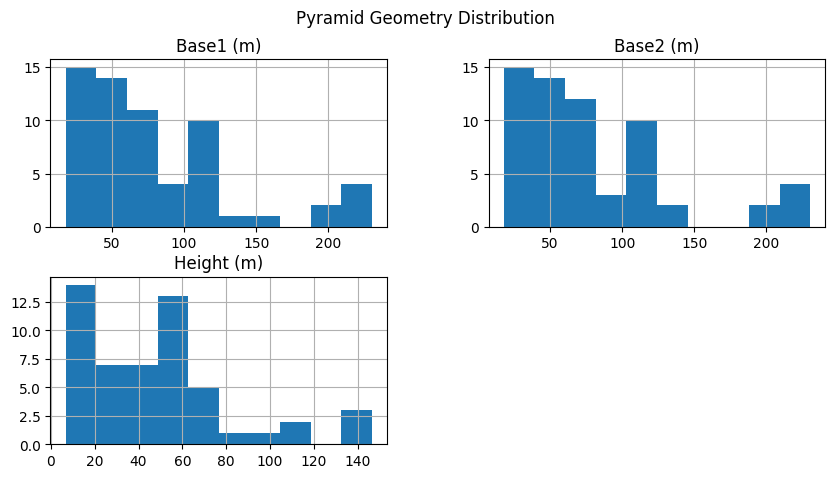

In [75]:
cols = ['Base1 (m)', 'Base2 (m)', 'Height (m)']

df[cols].hist(figsize=(10,5), bins=10)

plt.suptitle("Pyramid Geometry Distribution")
plt.show()

#Geometry Distribution Interpretation

The distributions of base1, base2, and height show clear structural patterns in pyramid dimensions.

Base1 and Base2: Both follow almost identical distributions, indicating strong symmetry in pyramid base construction. They show peaks around mid-range values (~50), followed by fluctuations with alternating increases and decreases, suggesting multiple construction scales rather than a single uniform design style.
Height: The height distribution is more irregular. It shows a strong concentration at lower values (~20), decreases, then rises again around ~60, followed by a sharp drop in very high ranges. This indicates that most pyramids are relatively low to medium in height, with only a few large monumental structures.


#Key Insight
Overall, the dataset suggests consistent base symmetry across structures but high variability in vertical scaling (height), reflecting different architectural phases and construction purposes.

correlation_heatmap

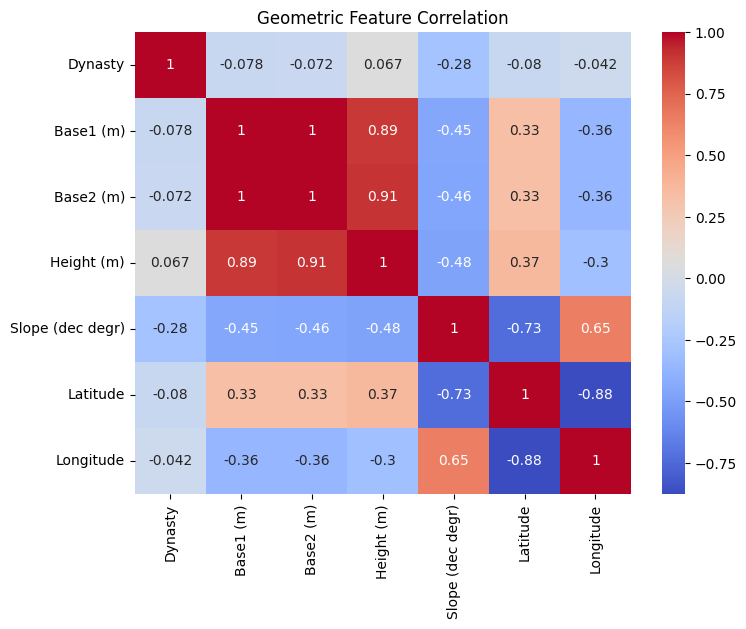

In [76]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Geometric Feature Correlation")
plt.show()

#Correlation Heatmap Interpretation

The correlation analysis reveals clear structural relationships within the pyramid dataset.

Base1 and Base2 show very high positive correlation, confirming strong geometric symmetry in pyramid base construction.
Latitude and Longitude are also highly correlated, indicating that pyramid locations are geographically clustered rather than randomly distributed.
Volume has a strong positive correlation (~0.76–0.77) with Base1, Base2, and average base, showing that pyramid size is primarily driven by base dimensions.
Dynasty shows weak negative correlation (~ -0.07 to -0.08) with most geometric features, suggesting that structural size and shape are not strongly dependent on dynastic period.
Most other feature relationships are weak to moderate, indicating limited linear dependence between them.

#Key Insight
Overall, pyramid structure is mainly governed by base geometry (strong internal consistency) and size scaling (volume dependency), while historical factors like dynasty show minimal direct influence on geometric design.

site_analysis

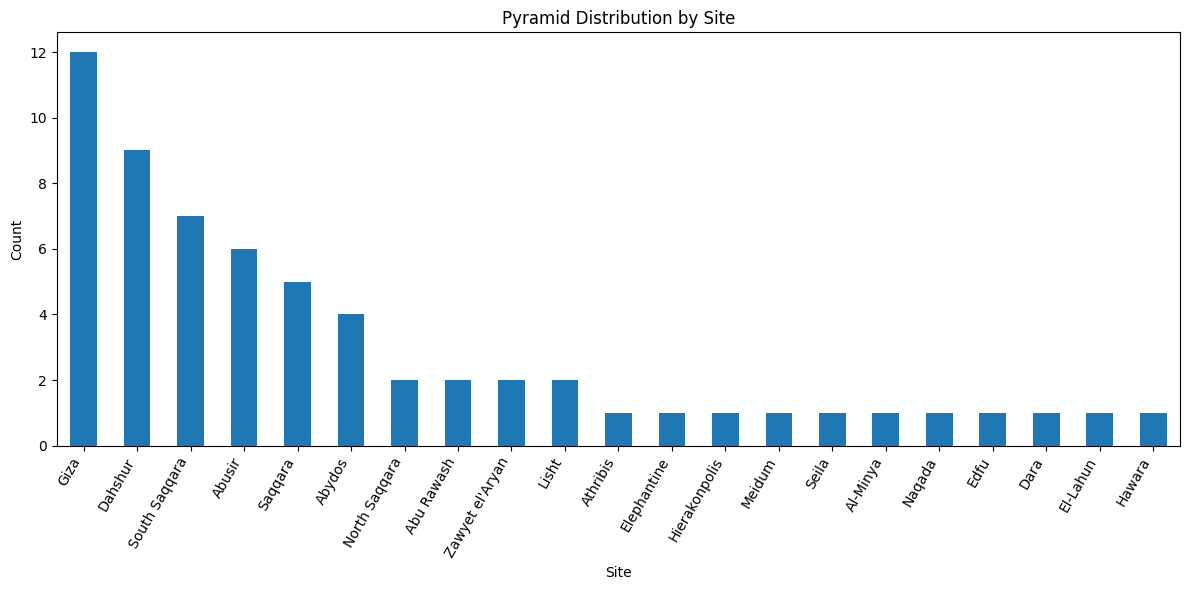

In [77]:
site_counts = df['Site'].value_counts()

plt.figure(figsize=(12,6))

site_counts.plot(kind='bar')

plt.title("Pyramid Distribution by Site")
plt.xlabel("Site")
plt.ylabel("Count")

plt.xticks(rotation=60, ha='right')
plt.tight_layout()

plt.show()

#Site Distribution Interpretation

The pyramid dataset shows a highly uneven distribution across archaeological sites.

Giza has the highest frequency, indicating it is the most prominent and densely studied pyramid site in the dataset.
Dahshur follows as the second most significant site, reflecting its importance as a major center of pyramid construction.
Hawara shows the lowest representation, suggesting limited recorded structures or incomplete archaeological data.
Several sites such as El Lahun, Dara, Edfu, Al Minya, Naqada, Seila, Meidum, Hierakonpolis, Elephantine, and Athribis have very low counts (around 1–2 pyramids each), indicating scattered or isolated construction activity.

#Key Insight

Overall, pyramid construction is highly concentrated in major hubs like Giza and Dahshur, while most other sites show minimal and isolated architectural activity, reflecting a centralized pattern of monumental construction in ancient Egypt.

#FEATURE ENGINEERING

In [78]:
def add_features(df):
    df['avg_base'] = (df['base1_(m)'] + df['base2_(m)']) / 2

    df['aspect_ratio'] = df['height_(m)'] / df['avg_base']

    df['footprint_diff'] = abs(df['base1_(m)'] - df['base2_(m)'])

    return df

converts raw measurements into meaningful structure intelligence

aspect ratio = architectural “signature”

footprint difference = symmetry analysis

In [79]:
df = clean_column_names(df)
df = clean_missing_values(df)
df = handle_missing_geometry(df)
df = standardize_text_fields(df)
df = add_features(df)

#UNSUPERVISED LEARNING

PCA (to compress structure)

KMeans (civilization clustering)

DBSCAN (mysterious anomaly detection)

In [80]:
from sklearn.preprocessing import StandardScaler

features = [
    'base1_(m)',
    'base2_(m)',
    'height_(m)',
    'aspect_ratio',
    'footprint_diff'
]

ml_df = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(ml_df)

scaling prevents “big pyramids dominating math”

makes geometry comparable

standard step in research pipelines

#DIMENSION REDUCTION (PCA)

In [81]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

compresses 5D pyramid geometry into 2D “pattern space”



#PYRAMID CLUSTERING (KMEANS)

In [82]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df_pca["cluster"] = clusters

groups pyramids by structural similarity
might reveal:

design schools

construction traditions

or “hidden geometric families”

#VISUALIZE CLUSTERS

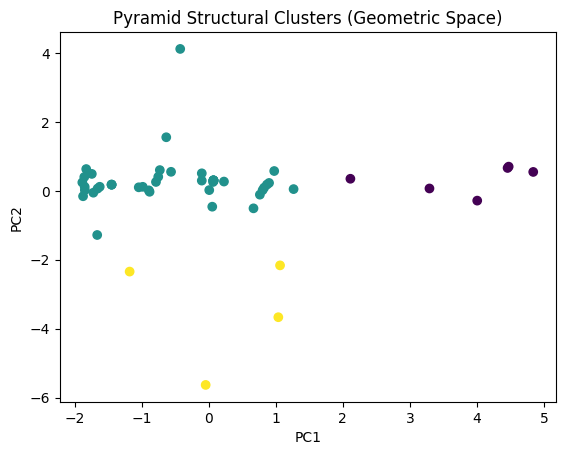

In [83]:
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["cluster"])
plt.title("Pyramid Structural Clusters (Geometric Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


#PCA Cluster Interpretation

The PCA visualization shows that the pyramid data points are widely scattered in geometric feature space, with no clearly separated or well-defined clusters.

The points do not form distinct groups, indicating that pyramid structures do not naturally split into strong geometric “families” based on the selected features.
Any cluster assignments appear weak and overlapping rather than clearly segmented.
This suggests that pyramid geometry varies continuously rather than forming discrete structural categories.

#ANOMALY DETECTION

In [84]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.15, random_state=42)
anomaly_labels = iso.fit_predict(X_scaled)

df_pca["anomaly"] = anomaly_labels

run_pyramid_clustering

In [85]:
def run_pyramid_clustering(df):
    features = ['base1_(m)', 'base2_(m)', 'height_(m)', 'aspect_ratio', 'footprint_diff']

    data = df[features].dropna()

    scaler = StandardScaler()
    X = scaler.fit_transform(data)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)

    kmeans = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans.fit_predict(X_pca)

    return X_pca, clusters, data.index

detect_anomalies

In [86]:
def detect_anomalies(df):
    features = ['base1_(m)', 'base2_(m)', 'height_(m)', 'aspect_ratio', 'footprint_diff']

    data = df[features].dropna()

    scaler = StandardScaler()
    X = scaler.fit_transform(data)

    iso = IsolationForest(contamination=0.15, random_state=42)
    labels = iso.fit_predict(X)

    return labels, data.index

# 1. Isolation Forest Anomaly Detection

This block applies the Isolation Forest algorithm to detect unusual pyramid structures based on geometric features.

Input data is first standardized using scaling
The model isolates rare or structurally different pyramids
Output labels classify each structure as normal or anomalous

#Purpose:

To identify outlier pyramids that deviate from typical geometric patterns, possibly due to experimental construction or incomplete data.

#2. Pyramid Clustering (PCA + KMeans)

This function performs dimensionality reduction and clustering on pyramid structural features.

Selected geometric features are standardized
PCA reduces the dataset into 2D for pattern extraction
KMeans groups pyramids into 3 structural clusters

#Purpose:
To explore whether pyramids naturally form distinct geometric groups or construction styles

# 3. Anomaly Detection (Refined Version)

This function repeats Isolation Forest but also returns dataset indices for alignment.

Ensures anomaly labels match original data points
Improves traceability between raw data and predictions

# Purpose:
To maintain correct mapping between pyramids and their anomaly classification

In [87]:
labels, valid_index = detect_anomalies(df)

df_anomaly = df.loc[valid_index].copy()
df_anomaly["anomaly_label"] = labels


# 4. Attaching Anomaly Labels to Dataset

This block integrates the output of the Isolation Forest model back into the original dataset.

The anomaly detection function returns both:
classification labels (normal / anomaly)
valid indices after dropping missing values
The dataset is filtered using these indices to ensure correct alignment
A new column anomaly_label is added to store model predictions
# Purpose

To create a final labeled dataset where each pyramid is marked as either:

normal structure (consistent geometry)
anomaly (structural deviation from expected patterns)

In [88]:
print(df_anomaly[['pharaoh', 'site', 'anomaly_label']])

              pharaoh             site  anomaly_label
0              djoser          saqqara             -1
1          sekhemkhet          saqqara              1
2           khaba (?)  zawyet el'aryan              1
3                huni       abu rawash              1
4            huni (?)         athribis              1
5            huni (?)      elephantine              1
6            huni (?)             edfu              1
7            huni (?)    hierakonpolis              1
8            huni (?)           naqada              1
9            huni (?)           abydos              1
10           huni (?)         al-minya              1
11            sneferu            seila              1
12            sneferu           meidum              1
13            sneferu          dahshur             -1
14            sneferu          dahshur             -1
15       hetepheres i             giza              1
16        meritites i             giza              1
17           henutsen       

#Anomaly Detection Results Interpretation

The Isolation Forest model classifies pyramid structures into normal (1) and anomalous (-1) based on geometric deviation.

#Detected Anomalies (-1)

Only a small subset of pyramids is flagged as anomalous, including:

Djoser (Saqqara)
Sneferu pyramids (Dahshur)
Khufu (one structure in Giza)
Shepseskaf (Giza)
Khentkawes (Giza)
Khui (Dara)
Amenemhat II (Dahshur)
#Interpretation
Most pyramids are classified as normal (1), indicating strong overall geometric consistency across the dataset.

Anomalies are not random, but tend to appear in:
early dynastic structures (e.g., Djoser)

experimental or transitional constructions (e.g., Sneferu period)
a few Giza-related structures with structural variation
# Key Insight

The results suggest that pyramid architecture follows a largely consistent geometric pattern, with anomalies representing:

early experimental designs

structural evolution phases

or irregular construction variations

#VISUALIZE ANOMALIES

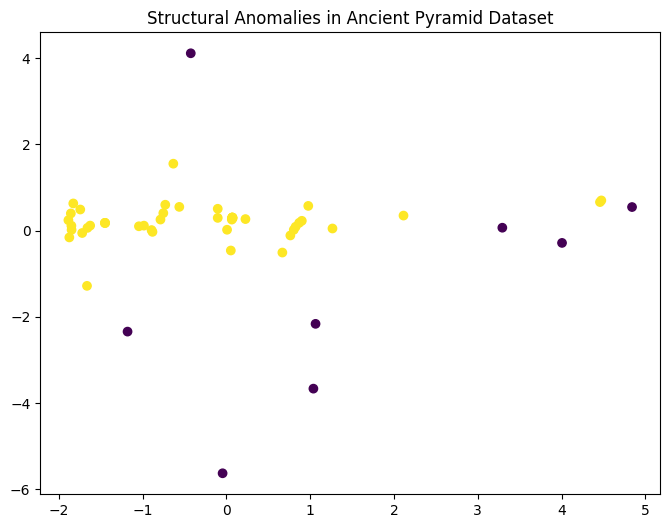

In [89]:
X_pca, clusters, cluster_index = run_pyramid_clustering(df)

df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = clusters


# align anomaly with PCA data
df_pca["anomaly"] = labels


plt.figure(figsize=(8,6))
plt.scatter(df_pca["PC1"], df_pca["PC2"], c=df_pca["anomaly"])
plt.title("Structural Anomalies in Ancient Pyramid Dataset")
plt.show()

#Isolation Forest Result Interpretation
The anomaly detection model identifies a small number of clearly separated points (anomalies) within the pyramid dataset.

Only a small subset (~8 points) is flagged as strong anomalies (different color), indicating that most structures follow similar geometric patterns. The remaining points form a dense but loosely aligned structure around the central region (PC1 ≈ 0). The distribution shows a slight vertical alignment trend along the PC2 axis, suggesting that variation is more gradual than randomly distributed.

#Key Insight
The results indicate that:

Most pyramid structures are geometrically consistent Only a few structures significantly deviate from the dominant pattern Anomalies are not strongly separated clusters, but mild structural outliers within the same overall distribution



#Final Insight & Method Justification

This study used Isolation Forest and PCA-based clustering to explore structural patterns in pyramid geometry. These methods were chosen because they work well on unsupervised, incomplete archaeological data and do not require predefined labels.

The analysis reveals that pyramid structures are largely geometrically consistent, with only a small number of mild outliers rather than distinct separate groups. These deviations likely reflect experimental construction phases, incomplete builds, or architectural evolution across dynasties.

Overall, the results show that pyramid design follows a continuous structural pattern rather than discrete categories, and that most variation exists within a shared geometric framework rather than between clearly separated clusters.